# AIS Data — Basic Exploration
**Date:** 2026-02-01 | **Source:** Danish Maritime Authority

This notebook loads one day of raw AIS data (~15 M records) from the DMA, filters to the Danish/Baltic core coverage area, and produces four starter visualisations:
1. Geographic vessel positions
2. Ship type distribution
3. Hourly message traffic
4. Speed-over-ground distribution

> **Note:** The DMA dataset covers Danish and adjacent waters (roughly lat 54–62 N, lon 7–17 E). For Antwerp/Zeebrugge analysis a Belgian/Dutch AIS feed is needed.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

DATA_PATH = '../data/raw/unzipped/aisdk-2026-02-01/aisdk-2026-02-01.csv'

## 1. Load & filter
Read in 200 k-row chunks and keep only the Danish/Baltic core area. This drops GPS artefacts (lat 91, lon 170) while preserving ~97 % of real records.

In [2]:
# Danish/Baltic core coverage area
BBOX = dict(lat_min=54.0, lat_max=62.0, lon_min=7.0, lon_max=17.0)

COLS = [
    '# Timestamp', 'Type of mobile', 'MMSI',
    'Latitude', 'Longitude', 'Navigational status',
    'SOG', 'Ship type',
]

chunks = []
for chunk in pd.read_csv(
    DATA_PATH,
    usecols=COLS,
    chunksize=200_000,
    low_memory=False,
):
    mask = (
        chunk['Latitude'].between(BBOX['lat_min'], BBOX['lat_max']) &
        chunk['Longitude'].between(BBOX['lon_min'], BBOX['lon_max'])
    )
    chunks.append(chunk[mask])

df = pd.concat(chunks, ignore_index=True)
df['timestamp'] = pd.to_datetime(df['# Timestamp'], dayfirst=True)
df['hour'] = df['timestamp'].dt.hour

print(f'Filtered records : {len(df):,}')
print(f'Unique vessels   : {df["MMSI"].nunique():,}')
df.head(3)

Filtered records : 14,892,156


Unique vessels   : 2,499


,# Timestamp,Type of mobile,MMSI,Latitude,Longitude,Navigational status,SOG,Ship type,timestamp,hour
0,01/02/2026 00:00:00,Class A,538004215,55.224783,13.255100,Under way using engine,10.8,Undefined,2026-02-01,0
1,01/02/2026 00:00:00,Class A,219018493,56.000300,8.129650,Under way using engine,0.0,Undefined,2026-02-01,0
2,01/02/2026 00:00:00,Base Station,2190064,56.716570,11.519047,Unknown value,NaN,Undefined,2026-02-01,0


## 2. Geographic vessel positions
Each point is one AIS ping. Colour encodes the top ship types. Major Danish ports are marked.

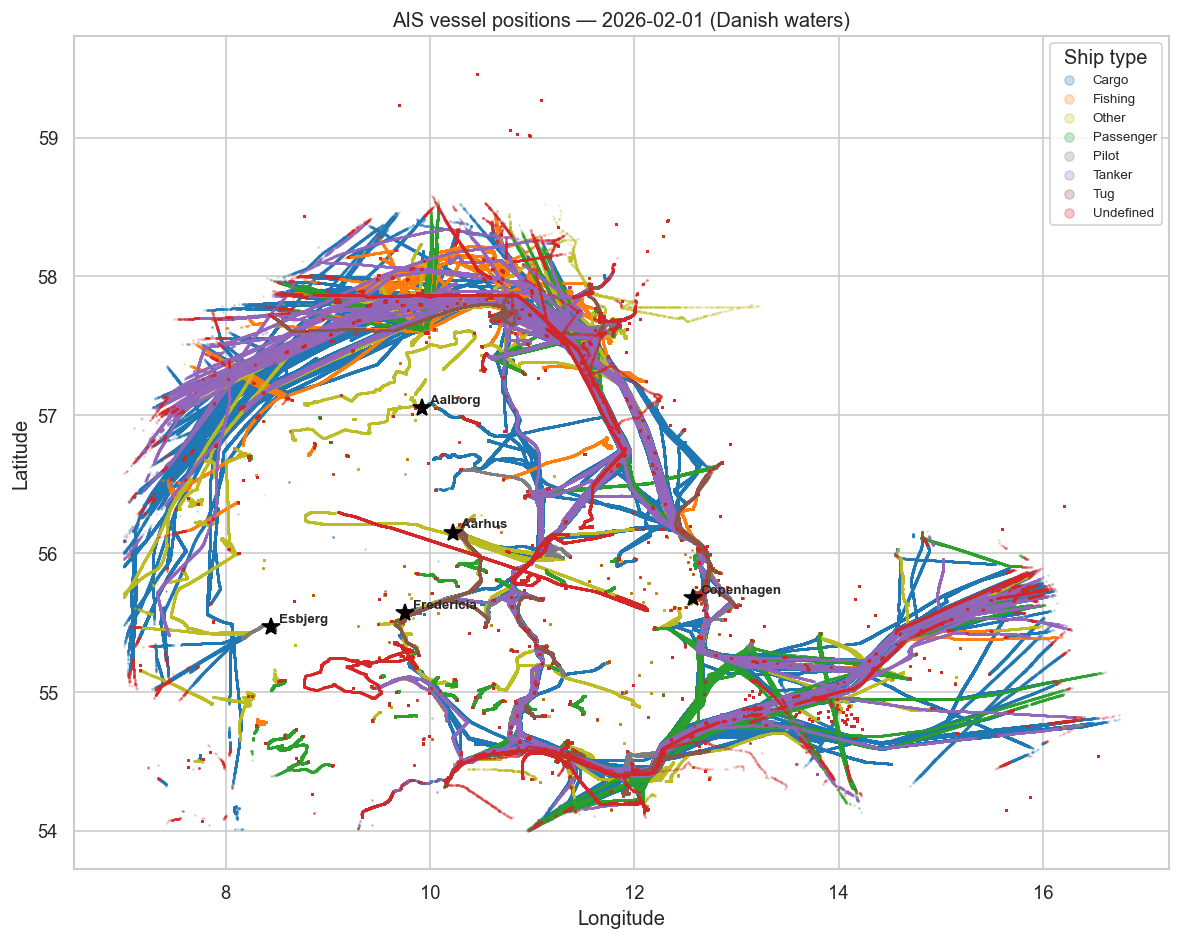

In [3]:
TOP_N = 8
top_types = df['Ship type'].value_counts().head(TOP_N).index.tolist()
df['ship_type_label'] = df['Ship type'].where(df['Ship type'].isin(top_types), other='Other')

palette = dict(zip(
    top_types + ['Other'],
    sns.color_palette('tab10', TOP_N + 1)
))

fig, ax = plt.subplots(figsize=(10, 8))

for label, group in df.groupby('ship_type_label'):
    ax.scatter(
        group['Longitude'], group['Latitude'],
        s=0.3, alpha=0.25,
        color=palette[label],
        label=label, rasterized=True,
    )

# Major Danish port markers
ports = {
    'Copenhagen': (12.57, 55.68),
    'Aarhus':     (10.22, 56.15),
    'Esbjerg':    (8.44,  55.47),
    'Aalborg':    (9.92,  57.05),
    'Fredericia': (9.75,  55.57),
}
for name, (lon, lat) in ports.items():
    ax.plot(lon, lat, marker='*', markersize=11, color='black', zorder=5)
    ax.annotate(name, (lon, lat), textcoords='offset points',
                xytext=(5, 3), fontsize=8, fontweight='bold')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('AIS vessel positions — 2026-02-01 (Danish waters)')
leg = ax.legend(title='Ship type', markerscale=10, loc='upper right',
                framealpha=0.85, fontsize=8)
fig.tight_layout()
plt.show()

## 3. Ship type distribution

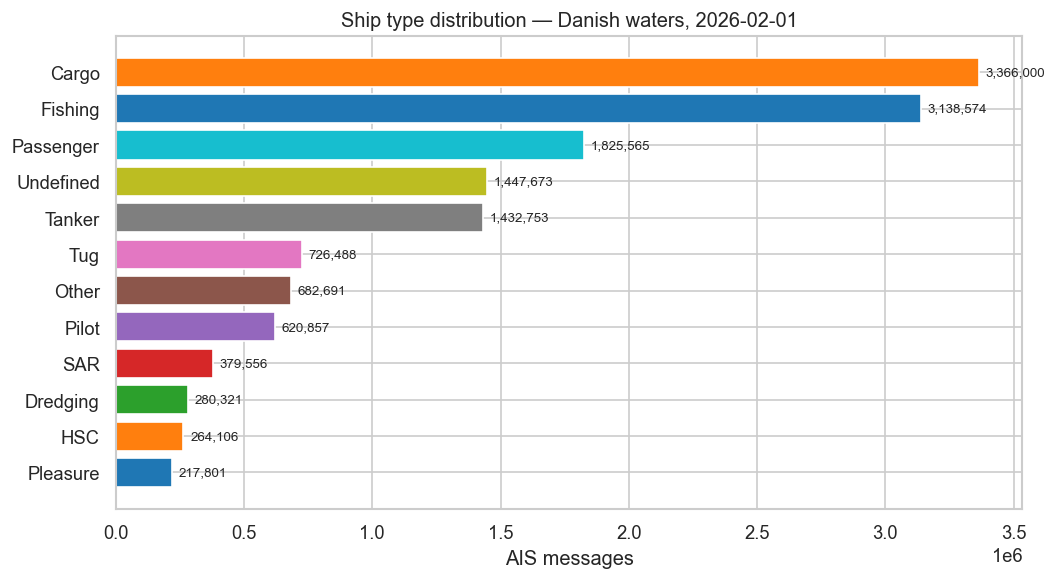

In [4]:
type_counts = (
    df['Ship type']
    .value_counts()
    .head(12)
    .reset_index()
    .rename(columns={'count': 'messages'})
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    type_counts['Ship type'][::-1],
    type_counts['messages'][::-1],
    color=sns.color_palette('tab10', len(type_counts)),
)
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=8)
ax.set_xlabel('AIS messages')
ax.set_title('Ship type distribution — Danish waters, 2026-02-01')
fig.tight_layout()
plt.show()

## 4. Hourly message traffic
Total AIS messages per hour — a proxy for vessel activity over the day.

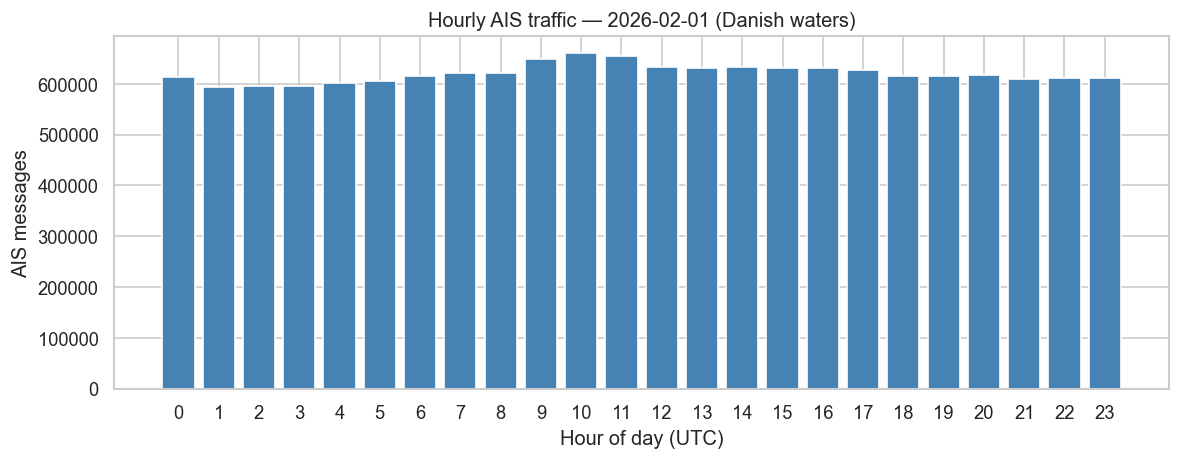

In [5]:
hourly = df.groupby('hour').size().reset_index(name='messages')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly['hour'], hourly['messages'], color='steelblue', edgecolor='white')
ax.set_xticks(range(24))
ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel('AIS messages')
ax.set_title('Hourly AIS traffic — 2026-02-01 (Danish waters)')
fig.tight_layout()
plt.show()

## 5. Speed-over-ground (SOG) distribution
Vessels at anchor / moored cluster near 0 knots; transiting vessels spread across 5–20 knots.

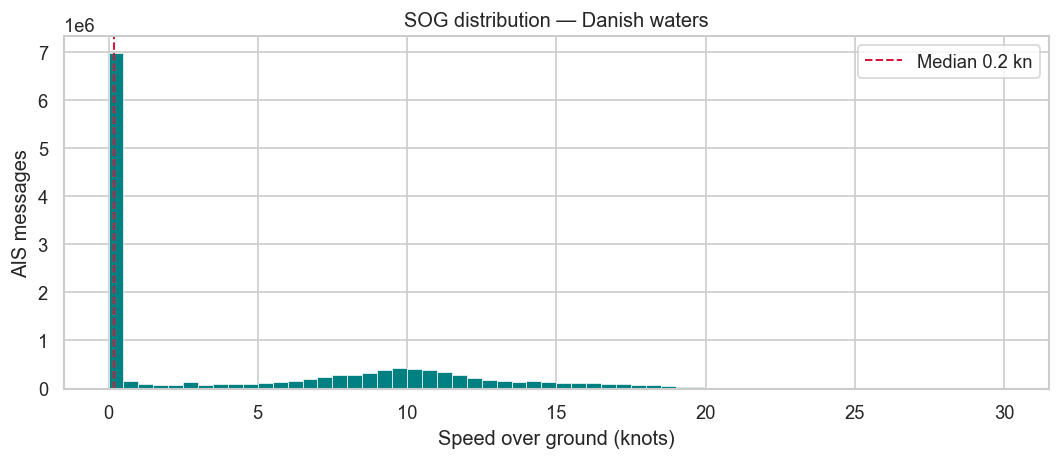

In [6]:
sog = df['SOG'].dropna()
sog = sog[(sog >= 0) & (sog <= 30)]   # cap at 30 kn — removes AIS artefacts

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sog, bins=60, color='teal', edgecolor='white', linewidth=0.4)
ax.axvline(sog.median(), color='crimson', linestyle='--', linewidth=1.2,
           label=f'Median {sog.median():.1f} kn')
ax.set_xlabel('Speed over ground (knots)')
ax.set_ylabel('AIS messages')
ax.set_title('SOG distribution — Danish waters')
ax.legend()
fig.tight_layout()
plt.show()

---
## Port-level analysis

The sections above cover all of Danish waters. Below we zoom into the five major ports — **Esbjerg, Aarhus, Copenhagen, Aalborg, Fredericia** — using the filtered Parquet output from `pipeline/filter.py` (one file per day, bounding-box reduced).

Analysis covers the full month of February 2026.

In [ ]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

FILTERED_DIR = Path('../data/processed/filtered')

# ── Load all filtered Parquet files ──────────────────────────────────────────
frames = []
for f in sorted(FILTERED_DIR.glob('aisdk-*.parquet')):
    df_day = pd.read_parquet(f)
    if df_day.empty:
        continue
    df_day['date'] = pd.to_datetime(f.stem.replace('aisdk-', '')).date()
    frames.append(df_day)

port_df = pd.concat(frames, ignore_index=True)
port_df['Timestamp'] = pd.to_datetime(port_df['Timestamp'], errors='coerce')
port_df['hour'] = port_df['Timestamp'].dt.hour

print(f'Total filtered records : {len(port_df):,}')
print(f'Days covered           : {port_df["date"].nunique()}')
print()
print(port_df.groupby('port')['MMSI'].agg(['count', 'nunique']).rename(
    columns={'count': 'pings', 'nunique': 'unique_vessels'}
))

### Daily vessel traffic trend
Unique vessels active per port per day — the primary traffic KPI.

In [ ]:
daily_vessels = (
    port_df.groupby(['port', 'date'])['MMSI']
    .nunique()
    .reset_index(name='vessel_count')
)
daily_vessels['date'] = pd.to_datetime(daily_vessels['date'])

PORTS_ORDER = ['esbjerg', 'aarhus', 'copenhagen', 'aalborg', 'fredericia']
palette = dict(zip(PORTS_ORDER, sns.color_palette('tab10', len(PORTS_ORDER))))

fig, ax = plt.subplots(figsize=(12, 5))
for port in PORTS_ORDER:
    sub = daily_vessels[daily_vessels['port'] == port]
    ax.plot(sub['date'], sub['vessel_count'],
            marker='o', markersize=4, linewidth=1.8,
            label=port.capitalize(), color=palette[port])

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
fig.autofmt_xdate()
ax.set_xlabel('Date')
ax.set_ylabel('Unique vessels')
ax.set_title('Daily vessel count by port — February 2026')
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

### Vessel type distribution per port

In [ ]:
TYPE_MAP = {
    'cargo': 'Cargo', 'tanker': 'Tanker', 'passenger': 'Passenger',
    'fishing': 'Fishing', 'tug': 'Tug', 'pleasure craft': 'Pleasure Craft',
    'hsc': 'HSC', 'sar': 'SAR',
}

def normalise_type(series):
    lowered = series.str.lower().str.strip().fillna('')
    result = pd.Series('Other', index=series.index)
    for key, label in TYPE_MAP.items():
        result[lowered.str.contains(key)] = label
    return result

port_df['vessel_type'] = normalise_type(port_df['Ship type'])

type_dist = (
    port_df.drop_duplicates(subset=['MMSI', 'port', 'date'])
    .groupby(['port', 'vessel_type'])
    .size()
    .reset_index(name='count')
)

fig, axes = plt.subplots(1, len(PORTS_ORDER), figsize=(16, 5), sharey=False)
type_palette = dict(zip(
    ['Cargo','Tanker','Passenger','Fishing','Tug','Pleasure Craft','HSC','SAR','Other'],
    sns.color_palette('tab10', 9)
))

for ax, port in zip(axes, PORTS_ORDER):
    sub = type_dist[type_dist['port'] == port].sort_values('count', ascending=True)
    colors = [type_palette.get(t, 'grey') for t in sub['vessel_type']]
    ax.barh(sub['vessel_type'], sub['count'], color=colors)
    ax.set_title(port.capitalize(), fontweight='bold')
    ax.set_xlabel('Unique vessel-days')
    if ax != axes[0]:
        ax.set_yticklabels([])

fig.suptitle('Vessel type distribution by port — February 2026', y=1.02)
fig.tight_layout()
plt.show()

### Dwell time distribution
Time between a vessel's first and last ping within a port bounding box on a given day. Long-tail vessels are anchored or awaiting berth; short visits are transits.

In [ ]:
visits = (
    port_df.groupby(['MMSI', 'port', 'date'])['Timestamp']
    .agg(first='min', last='max')
    .reset_index()
)
visits['dwell_hours'] = (
    (visits['last'] - visits['first']).dt.total_seconds() / 3600
)

fig, axes = plt.subplots(1, len(PORTS_ORDER), figsize=(16, 4), sharey=True)

for ax, port in zip(axes, PORTS_ORDER):
    dwell = visits[(visits['port'] == port) & (visits['dwell_hours'] > 0)]['dwell_hours']
    dwell = dwell[dwell <= 24]   # cap at 24h for readability
    ax.hist(dwell, bins=30, color=palette[port], edgecolor='white', linewidth=0.4)
    ax.axvline(dwell.median(), color='black', linestyle='--', linewidth=1,
               label=f'Median {dwell.median():.1f}h')
    ax.set_title(port.capitalize(), fontweight='bold')
    ax.set_xlabel('Dwell (hours)')
    ax.legend(fontsize=7)

axes[0].set_ylabel('Vessel-visits')
fig.suptitle('Dwell time distribution by port — February 2026', y=1.02)
fig.tight_layout()
plt.show()

### Congestion heatmap
Average vessel count by hour-of-day × day-of-week. Reveals whether ports are 24/7 operations or have distinct working-hours patterns.

In [ ]:
port_df['dow'] = pd.to_datetime(port_df['date']).dt.dayofweek  # 0=Mon

hourly_counts = (
    port_df.groupby(['port', 'date', 'dow', 'hour'])['MMSI']
    .nunique()
    .reset_index(name='vessel_count')
)
heat = (
    hourly_counts.groupby(['port', 'dow', 'hour'])['vessel_count']
    .mean()
    .reset_index()
)

DOW_LABELS = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, len(PORTS_ORDER), figsize=(18, 5))

for ax, port in zip(axes, PORTS_ORDER):
    pivot = (
        heat[heat['port'] == port]
        .pivot(index='dow', columns='hour', values='vessel_count')
        .reindex(range(7))
    )
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', linewidths=0,
                cbar=ax == axes[-1], yticklabels=DOW_LABELS)
    ax.set_title(port.capitalize(), fontweight='bold')
    ax.set_xlabel('Hour (UTC)')
    ax.set_ylabel('')

axes[0].set_ylabel('Day of week')
fig.suptitle('Avg vessel count — hour × day-of-week (Feb 2026)', y=1.02)
fig.tight_layout()
plt.show()

### Geographic scatter within port bounding boxes
AIS pings within each port's bounding box, coloured by vessel type.

In [ ]:
from config import PORTS as PORT_BOXES

# Sample for speed — 5k points per port
SAMPLE = 5_000

fig, axes = plt.subplots(1, len(PORTS_ORDER), figsize=(18, 5))

for ax, port in zip(axes, PORTS_ORDER):
    sub = port_df[port_df['port'] == port]
    if len(sub) > SAMPLE:
        sub = sub.sample(SAMPLE, random_state=42)

    for vtype, grp in sub.groupby('vessel_type'):
        ax.scatter(grp['Longitude'], grp['Latitude'],
                   s=1.5, alpha=0.4, label=vtype,
                   color=type_palette.get(vtype, 'grey'),
                   rasterized=True)

    lat_min, lat_max, lon_min, lon_max = PORT_BOXES[port]
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_title(port.capitalize(), fontweight='bold')
    ax.set_xlabel('Lon')
    ax.set_ylabel('Lat' if ax == axes[0] else '')
    ax.tick_params(labelsize=7)

# Shared legend on last axis
handles, labels = axes[-1].get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    seen.setdefault(l, h)
axes[-1].legend(seen.values(), seen.keys(), markerscale=5,
                fontsize=7, loc='upper right')

fig.suptitle('AIS pings within port bounding boxes — Feb 2026 (sampled)', y=1.02)
fig.tight_layout()
plt.show()